In [2]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import sklearn.linear_model as lnm
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [3]:
def get_var_size():
    # Get all variables in the current namespace
    variables = {name: value for name, value in globals().items() if not name.startswith("__")}

    # Sort variables by size
    sorted_vars = sorted(variables.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

    # Print variable sizes
    for name, value in sorted_vars:
        print(f"{name}: {sys.getsizeof(value) / 1024:.2f} KB")

In [4]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)


In [5]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=20


In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [7]:
behave_dict = {}

for behavior in behaviors:
    behave_dir = os.path.join(later_dir, behavior)
#     print(behave_dir)
    behave_dict[behavior]=[]
    for file in os.listdir(behave_dir):
        if 'STA' in file and str(step_size) in file:
            STA_path=os.path.join(behave_dir, file)
            with h5py.File(STA_path, 'r') as sf:
                brain = sf['data'][:]
                brain[np.isnan(brain)] = 0
                brain[np.isinf(brain)] = 4
                brain = np.moveaxis(brain, 0, -1)
                dims=np.shape(brain)
                print(f'brain shape: {dims}')
                behave_dict[behavior]=brain
                

brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)
brain shape: (314, 146, 91, 120)


In [47]:
behave_dict.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

In [59]:
np.shape(giant_cluster_labels)

(91, 45844)

In [48]:
%%time
supervox_dict={}
for behave in behaviors:
    supervox_dict[behave]=[]
    brain = behave_dict[behave]
    dims = np.shape(brain)
#     supervox_dict[behave]['signals']=[]
    for z in range(dims[-2]):
        neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
#         print(np.shape(neural_activity))
        signals = []
        for cluster_num in range(n_clusters):
            cluster_indicies = np.where(giant_cluster_labels[z,:]==cluster_num)[0]
            mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
            signals.append(mean_signal)
        signals = np.asarray(signals)
        supervox_dict[behave].append(signals)
    supervox_dict[behave] = np.asarray(supervox_dict[behave])
    print(np.shape(supervox_dict[behave]))

(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)
(45844, 120)

In [10]:
1000/int(2500/120)

50.0

In [11]:
## Apply lowpass filter
order=3
fs=1000/int(2500/np.shape(supervox_dict['total']['signals'])[-1])
f0=5
b, a = butter(order, f0/(fs/2), btype='low', analog=False)
lowpass_dict={}
for behave in supervox_dict:
    lowpass = filtfilt(b, a, supervox_dict[behave]['signals'], axis=-1)
    lowpass_dict[behave]=lowpass

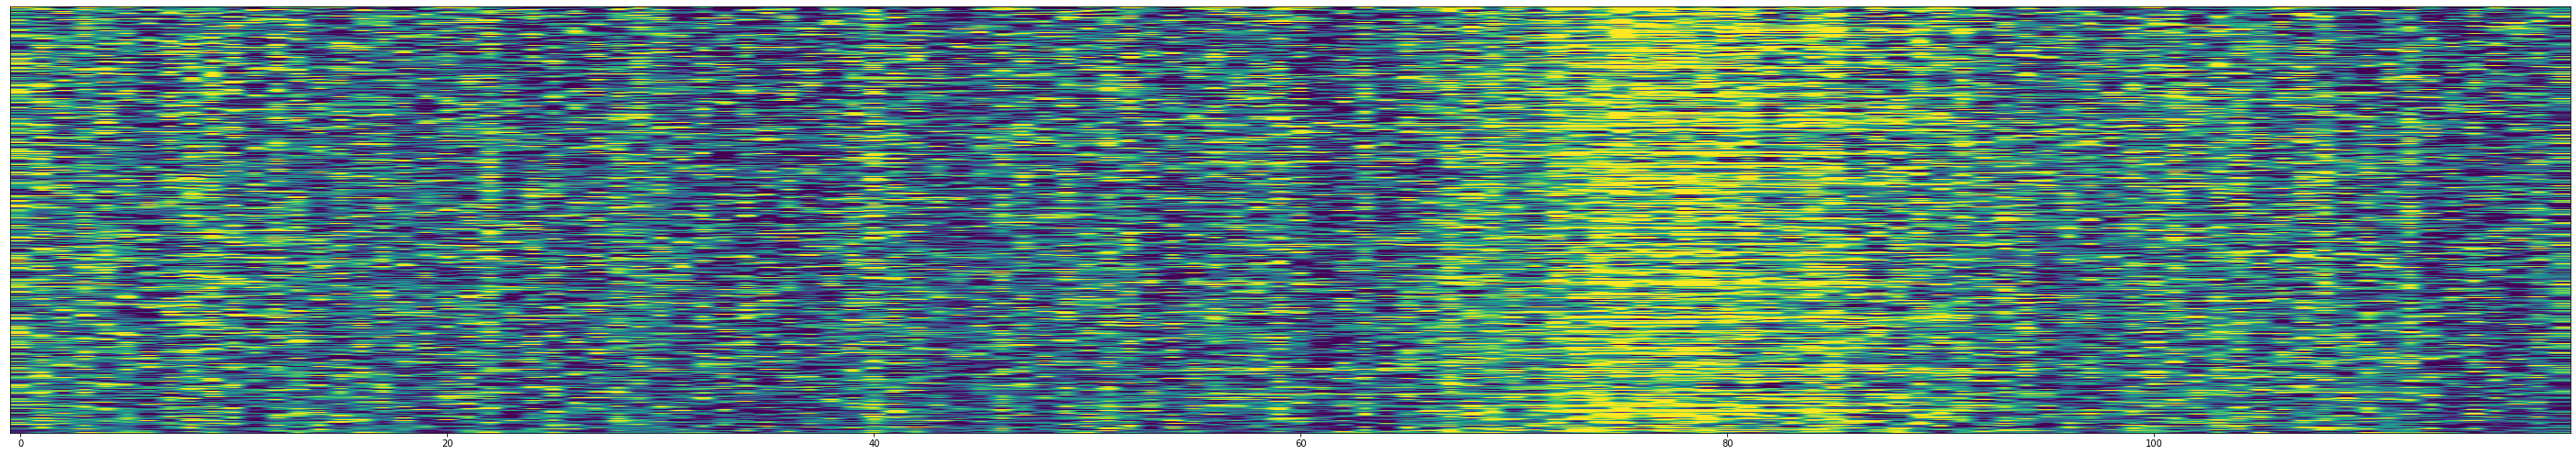

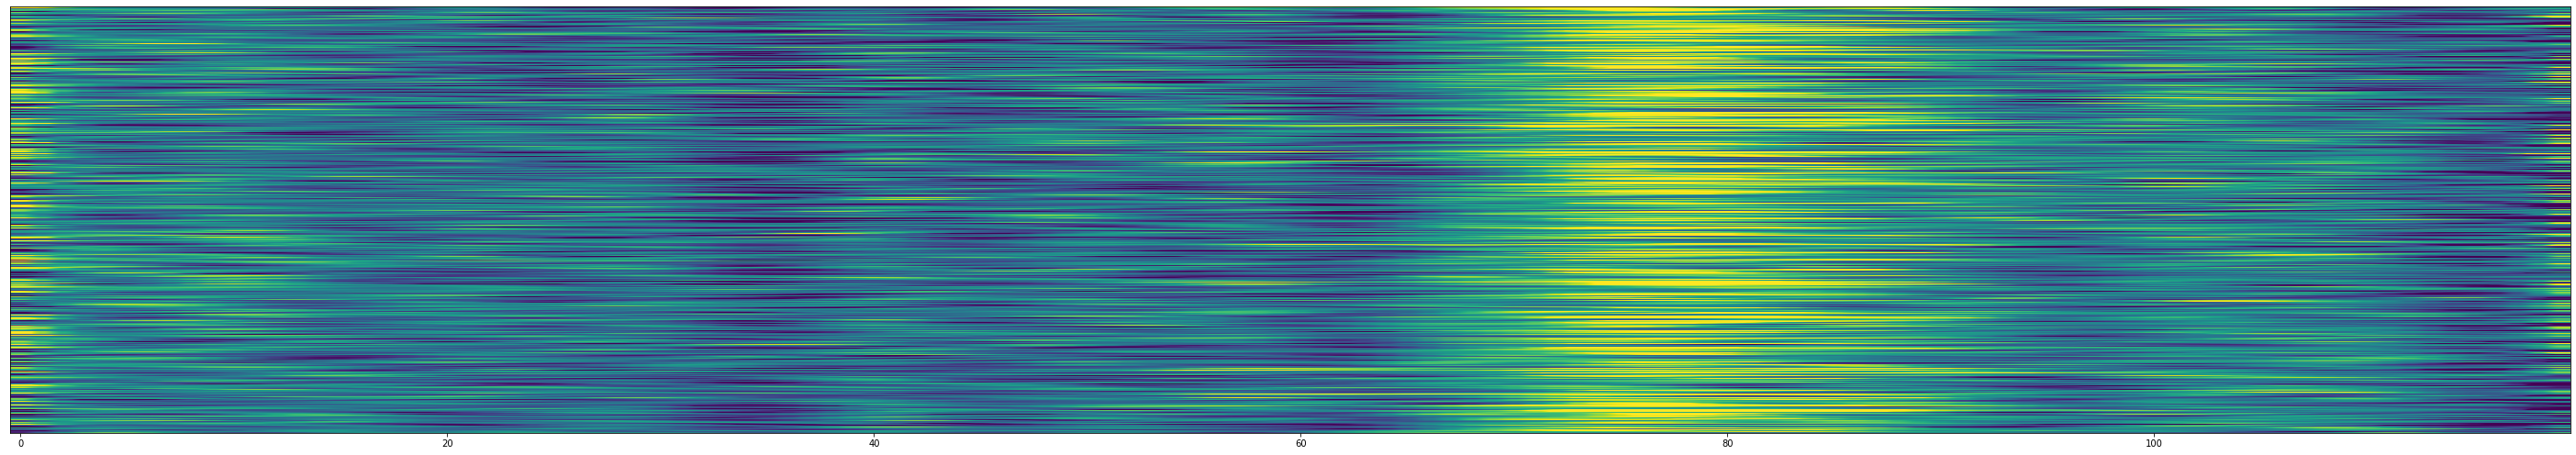

In [12]:
behave='flat'
fig,axs = plt.subplots(figsize=(50,100))
axs.imshow(supervox_dict[behave]['signals'][50], vmax=0.01, vmin=-0.01)
axs.set_yticks([])
axs.set_aspect(0.01)
# fig,axs = plt.subplots(figsize=(50,100))
# axs.imshow(blur_data[50], vmax=0.01, vmin=-0.01)
# # axs.axvline((np.arange(0,120,20)), color='k')
# axs.set_yticks([])
# axs.set_aspect(0.01)
fig,axs = plt.subplots(figsize=(50,100))
axs.imshow(lowpass_dict[behave][50], vmax=0.01, vmin=-0.01)
# axs.axvline((np.arange(0,120,20)), color='k')
axs.set_yticks([])
axs.set_aspect(0.01)

In [13]:
600/20

30.0

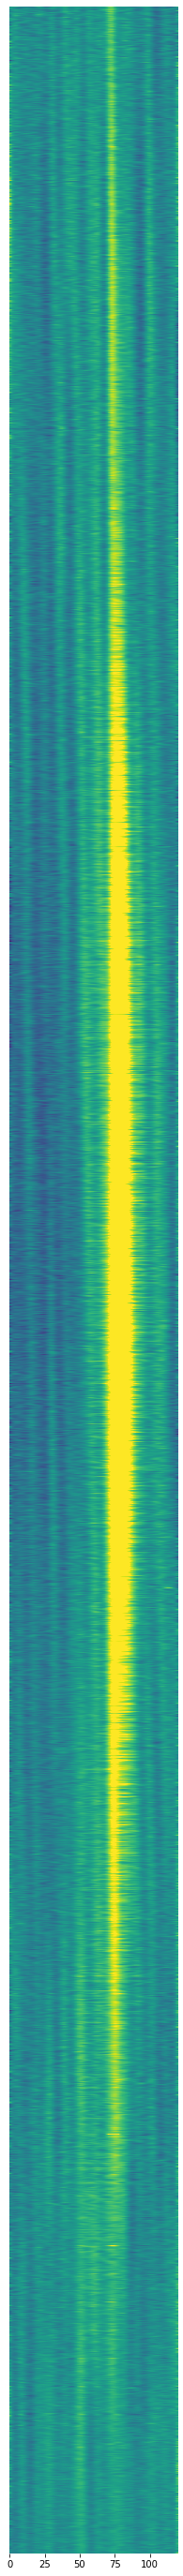

In [14]:
b='total'
data=lowpass_dict[b]
num_areas=np.shape(data)[0]
fig = plt.figure(figsize=(10,50))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    axs[i].imshow(data[i], vmax=0.005, vmin=-0.005)
    axs[i].set_yticks([])
#     axs[i].set_xticks([])
    axs[i].set_aspect(0.01)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()

In [15]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [16]:
# %%time
# # roi_num=np.full((dims_test[0], dims_test[1]), np.nan)
# # print(np.shape(roi_num))
# # roi_name=np.zeros((dims_test[0], dims_test[1]), dtype=str)
key_to_name={}
dims=np.shape(giant_cluster_labels)
giant_area_labels=np.zeros_like(giant_cluster_labels)
for area in explosion_rois:
    for key in explosion_rois[area]['rois']:
        area_name=explosion_rois[area]['rois'][key]
        if '_R' in area_name or '_L' in area_name:
            total_area_name=area_name.split('_')
            if len(total_area_name)==3:
                area_name=total_area_name[0]+'_'+total_area_name[1]
            else:
                area_name=total_area_name[0]
#         print(area_name)
        roi=key
        if key in key_to_name:
            key_to_name.append(area_name)
        else:
            key_to_name[roi]=area_name
        area_mask=np.asarray(roi_masks[roi])
        area_mask_flat=area_mask.reshape(dims[0], dims[1])
        giant_area_labels=np.where(area_mask_flat==False, giant_area_labels, roi)
#         print(np.shape(giant_area_labels))
#         print(np.count_nonzero(giant_area_labels))
#         print(f'ROI num: {np.count_nonzero(giant_area_labels==roi)}')

In [17]:
print(np.shape(giant_cluster_labels[50,:]))
print(np.nanmax(giant_area_labels[50,:]))
test=np.copy(giant_area_labels)

(45844,)
83


In [18]:
x,y,t = np.shape(supervox_dict[behave]['signals'])
cluster_rois = np.zeros((x,y))
# np.shape(cluster_rois)
for i in range(x):
    for j in range(y):
        idxs=np.where(giant_cluster_labels[i]==j)
#         print(f'Z {i} and cluster {j} have areas {np.unique(test[i][idxs])}')

In [19]:
# key_to_name

In [20]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
    supervox_brain=gaussian_filter(lowpass_dict[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(120, 314, 146, 91)
inc
(120, 314, 146, 91)
dec
(120, 314, 146, 91)
flat
(120, 314, 146, 91)
CPU times: user 53.7 s, sys: 6.29 s, total: 1min
Wall time: 1min


In [21]:
%%time

def moving_average_2d(arr, window_size=25):
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
    # Find the index of the maximum value in each row
    arr_avg=moving_average_2d(arr,window_size=5)
    max_indices = np.argmax(arr_avg, axis=1)
    
    # Get the sorted order of the rows based on the max indices
    sorted_order = np.argsort(max_indices)
    
    # Sort the rows of the array based on the sorted order
    sorted_arr = arr[sorted_order]
    return sorted_arr


total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
            masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi
for behavior in total_vox_sorted:
    for key in total_vox_sorted[behavior]:
        total_vox_sorted[behavior][key]=sort_rows_by_max_index(total_vox_sorted[behavior][key])

CPU times: user 42.2 s, sys: 2.41 s, total: 44.6 s
Wall time: 44.6 s


In [22]:
np.shape(total_vox_sorted[behavior]['FB'])

(12480, 120)

In [23]:
step_size=20
step_10=np.array([[0.00006,-0.00002],[60,160]])
step_100=np.array([[0.01,-0.003],[6,16]])
step_20=np.array([[0.007,-0.003],[30,80]])

In [24]:
def plot_heatmap_area(areas_dict, area, ax, step_size):
    if step_size==10:
        stuff=step_10
    elif step_size==20:
        stuff=step_20
    else:
        stuff=step_100
    ax.imshow(areas_dict[area], aspect='auto',vmax=stuff[0,0], vmin=stuff[0,1], cmap='plasma')
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.set_yticks([])

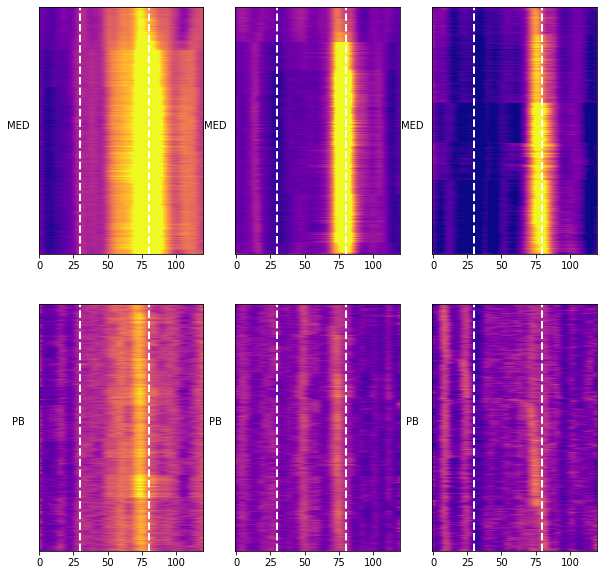

In [25]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10,10))
plot_heatmap_area(total_vox_sorted['inc'], 'MED', axs[0,0], step_size)
plot_heatmap_area(total_vox_sorted['dec'], 'MED', axs[0,1], step_size)
plot_heatmap_area(total_vox_sorted['flat'], 'MED', axs[0,2], step_size)
plot_heatmap_area(total_vox_sorted['inc'], 'PB', axs[1,0], step_size)
plot_heatmap_area(total_vox_sorted['dec'], 'PB', axs[1,1], step_size)
plot_heatmap_area(total_vox_sorted['flat'], 'PB', axs[1,2], step_size)

In [26]:
def plot_heatmap_allareas(areas_dict):
    num_areas=len(areas_dict)
    heights = [np.shape(areas_dict[key])[0] for key in areas_dict]
    heights = heights/np.min(heights)
    heights_final = [int(x) for x in heights]
    fig = plt.figure(figsize=(5,10))
    gs = fig.add_gridspec(nrows=num_areas, ncols=1, height_ratios=heights, hspace=0)
    axs = gs.subplots(sharex='col', sharey=False)
    for i,key in enumerate(areas_dict):
        plot_heatmap_area(areas_dict, key, axs[i],step_size)
    for ax in axs:
        ax.label_outer()
#         ax.spines['top'].set_visible(False)
#         ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
#         ax.set_yticks([])
        
    plt.show()

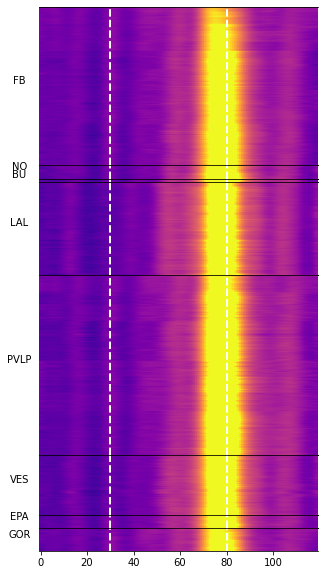

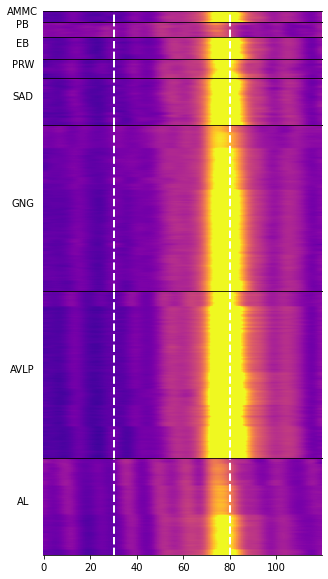

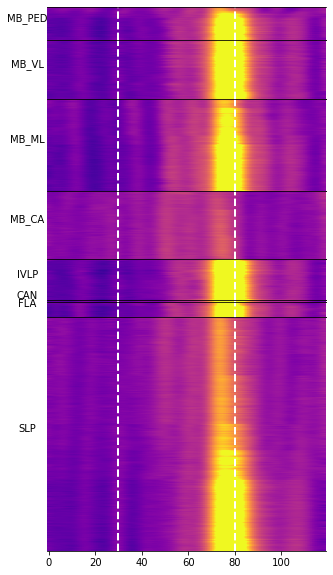

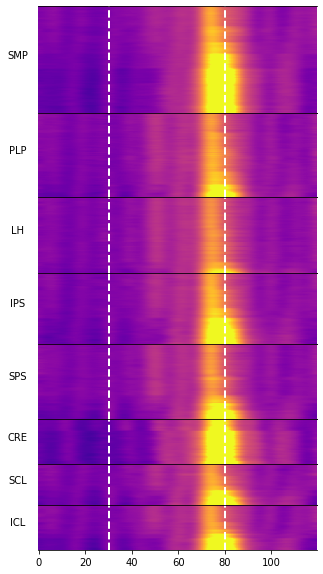

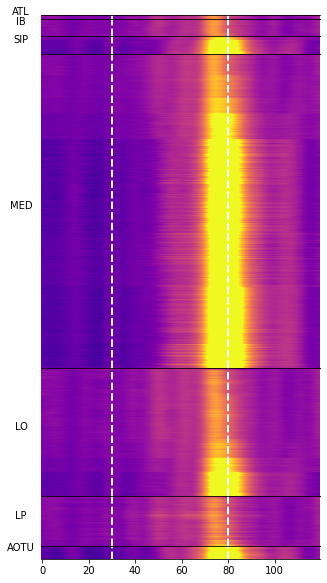

In [27]:
behavior='total'
areas = int((len(total_vox_sorted[behavior])+1)/5)
for i in range(0,len(total_vox_sorted[behavior]), areas):
    end = i + areas if i + areas < len(total_vox_sorted[behavior]) else len(total_vox_sorted[behavior])
    sliced_keys = list(total_vox_sorted[behavior].keys())[i:end]
    sliced_dict = {k: total_vox_sorted[behavior][k] for k in sliced_keys if k in total_vox_sorted[behavior]}
    plot_heatmap_allareas(sliced_dict)

In [28]:
total_vox_sorted[behavior].keys()

dict_keys(['FB', 'NO', 'BU', 'LAL', 'PVLP', 'VES', 'EPA', 'GOR', 'AMMC', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP', 'AL', 'MB_PED', 'MB_VL', 'MB_ML', 'MB_CA', 'IVLP', 'CAN', 'FLA', 'SLP', 'SMP', 'PLP', 'LH', 'IPS', 'SPS', 'CRE', 'SCL', 'ICL', 'ATL', 'IB', 'SIP', 'MED', 'LO', 'LP', 'AOTU'])

In [29]:
def get_rois(explosion_rois, roi_group, roi_masks, data_to_plot, roi_contours, vmax, cmap, diverging, roi=None):
    x_shift = explosion_rois[roi_group]['x_shift']
    y_shift = explosion_rois[roi_group]['y_shift']

    roi_data = []
    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []

    if roi==None:
        for roi in explosion_rois[roi_group]['rois']:
            mask = roi_masks[roi]
            #masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
            masked_roi = mask*data_to_plot

            ### maximum projection along z-axis
            # works for negative values
            maxs = np.max(masked_roi,axis=2)
            mins = np.min(masked_roi,axis=2)
            maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
            roi_data.append(maxs)
            #masked_roi_flat = maxs

            ### maximum projection along z-axis
            #masked_roi_flat = np.max(masked_roi,axis=2)
            #roi_data.append(masked_roi_flat)

            left_edges.append(roi_contours[roi]['left_edge'])
            right_edges.append(roi_contours[roi]['right_edge'])
            top_edges.append(roi_contours[roi]['top_edge'])
            bottom_edges.append(roi_contours[roi]['bottom_edge'])
    else:
        mask = roi_masks[roi]
        #masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
        masked_roi = mask*data_to_plot

        ### maximum projection along z-axis
        # works for negative values
        maxs = np.max(masked_roi,axis=2)
        mins = np.min(masked_roi,axis=2)
        maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
        roi_data.append(maxs)
        #masked_roi_flat = maxs

        ### maximum projection along z-axis
        #masked_roi_flat = np.max(masked_roi,axis=2)
        #roi_data.append(masked_roi_flat)

        left_edges.append(roi_contours[roi]['left_edge'])
        right_edges.append(roi_contours[roi]['right_edge'])
        top_edges.append(roi_contours[roi]['top_edge'])
        bottom_edges.append(roi_contours[roi]['bottom_edge'])


    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1

    ### this projects across all the roi_data from each roi 
    #roi_datas = np.max(np.asarray(roi_data),axis=0) # this one line is sufficient for not diverging
    maxs = np.max(np.asarray(roi_data),axis=0)
    mins = np.min(np.asarray(roi_data),axis=0)
    maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
    roi_datas = maxs

    ###ADD MAX MIN HERE LIKE ABOVE

    ### cutout this grouping
    #data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge,:],0,1) # for 3 channel
    data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge],0,1)
    ### apply gain
    #data_map = data_map * gain

    mycmap = matplotlib.cm.get_cmap(cmap)
    #mycmap.set_bad('k',1) # make nans black

    if diverging:
        # this will normalize all value to [0,1], with 0.5 being the new "0" basically
        # current issue - a zero that should be background now looks like negative.
        # solution: could use nans instead and set bad color
        # with diverging we should make background white!
        # so actually just set the input_canvas as 0.5!!!
        # then make contours nan and set back as black
        norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
        data_map = norm(data_map)
    else:
        data_map = data_map/vmax

    data_map = mycmap(data_map)[...,:3] #lose alpha channel

#     dims = get_dim_info(data_map, full_x_mid, full_y_mid)
    return data_map

In [30]:
to_look={}
behavior='flat'
to_look['begin']=full_res[behavior][10]
to_look['before']=full_res[behavior][25]
to_look['during']=full_res[behavior][75]
to_look['over']=full_res[behavior][85]
to_look['end']=full_res[behavior][100]

In [31]:
len(to_look)

5

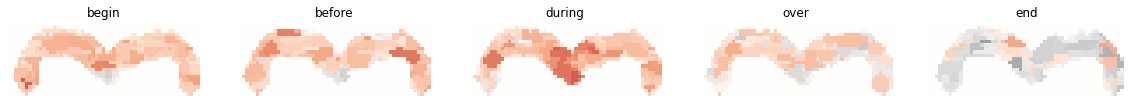

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=len(to_look), figsize=(20,5))
count=0
for key in to_look:
    if count<len(to_look):
        data_map=get_rois(explosion_rois, 'PB', roi_masks, to_look[key], roi_contours, vmax=0.01, cmap='RdGy_r', diverging=True)
        axs[count].imshow(data_map)
        axs[count].axis('off')
        axs[count].set_title(key)
        count+=1

In [58]:
super_clusters=5000
shape= np.shape(supervox_dict['total'])
connectivity = grid_to_graph(shape[0],shape[1])
super_labels = []

brain=supervox_dict['total']
neural_activity = brain.reshape(-1, shape[2])
print(np.shape(connectivity))
# cluster_model = AgglomerativeClustering(n_clusters=super_clusters,
#                             memory=cluster_dir,
#                             linkage='ward',
#                             connectivity=connectivity)
# cluster_model.fit(neural_activity)
# super_labels.append(cluster_model.labels_)
# super_labels = np.asarray(super_labels)
# print(np.shape(super_labels))

# super_duper={}
# for behave in supervox_dict:
#     super_duper[behave]={}
#     brain = supervox_dict[behave]
#     dims = np.shape(brain)
#     super_duper[behave]=[]
#     neural_activity = brain.reshape(-1, dims[2])
#     print(np.shape(neural_activity))
#     signals = []
#     for cluster_num in range(super_clusters):
#         cluster_indicies = np.where(super_labels==cluster_num)[0]
#         mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
#         signals.append(mean_signal)
#     signals = np.asarray(signals)
#     supervox_dict[behave]['signals'].append(signals)
# supervox_dict[behave]['signals'] = np.asarray(supervox_dict[behave]['signals'])
# print(np.shape(supervox_dict[behave]['signals']))

(182000, 182000)
